# AutoEIT — Segmentation Log Analysis
Parses the segmentation pipeline log and produces summary statistics and plots.

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
from pathlib import Path

## Config

In [4]:
LOG_PATH = Path("../../metis_logs/autoeit_transcribe.o165199")  # adjust as needed

## Parse log

In [15]:
# Patterns
RE_PROCESSING  = re.compile(r"INFO Processing (.+)$")
RE_VAD_SEGS    = re.compile(r"INFO Found (\d+) speech segments")
RE_MERGED      = re.compile(r"INFO Merged into (\d+) EIT items")
RE_EXPORTED    = re.compile(r"INFO Exported (\d+) segments")
RE_ATTENTION   = re.compile(r"WARNING Item (\d+) is longer than 10s")
RE_VERSION     = re.compile(r"([AB])\.\w+$", re.IGNORECASE)

records = []
attention_flags = defaultdict(list)  # filename -> [item indices]

current_file = None
current = {}

with open(LOG_PATH) as f:
    for line in f:
        line = line.strip()

        m = RE_PROCESSING.search(line)
        if m:
            if current_file and current:
                records.append(current)
            current_file = m.group(1).strip()
            ver_m = RE_VERSION.search(current_file)
            version = ver_m.group(1).upper() if ver_m else "unknown"
            current = {"file": current_file, "version": version,
                       "vad_segments": None, "eit_items": None,
                       "exported": None, "attention_count": 0}
            continue

        m = RE_VAD_SEGS.search(line)
        if m and current:
            current["vad_segments"] = int(m.group(1))
            continue

        m = RE_MERGED.search(line)
        if m and current:
            current["eit_items"] = int(m.group(1))
            continue

        m = RE_EXPORTED.search(line)
        if m and current:
            current["exported"] = int(m.group(1))
            continue

        m = RE_ATTENTION.search(line)
        if m and current_file:
            idx = int(m.group(1))
            attention_flags[current_file].append(idx)
            if current:
                current["attention_count"] += 1

# flush last record
if current:
    records.append(current)

df = pd.DataFrame(records)
# collapse_ratio: how many VAD segments collapsed into one EIT item on average
df["collapse_ratio"] = df["vad_segments"] / df["eit_items"]

print(f"Parsed {len(df)} recordings")
df.head()

Parsed 206 recordings


,file,version,vad_segments,eit_items,exported,attention_count,collapse_ratio
0,038053_EITv-2A.mp3,A,65,39,39,1,1.666667
1,038032_EITv-2A.mp3.mp3,unknown,53,37,37,1,1.432432
2,038004_EIT-2A.mp3,A,63,36,36,0,1.750000
3,038019_EIT-1A.mp3,A,58,37,37,0,1.567568
4,038046_EITv-2A.mp3,A,76,38,38,0,2.000000


## 1. Summary statistics — overall and by version

In [16]:
cols = ["vad_segments", "eit_items", "collapse_ratio", "attention_count"]

print("=== Overall ===")
display(df[cols].describe().round(2))

print("\n=== By version ===")
display(df.groupby("version")[cols].describe().round(2))

=== Overall ===


,vad_segments,eit_items,collapse_ratio,attention_count
count,206.00,206.00,206.00,206.00
mean,79.13,41.33,1.94,1.48
std,34.41,12.18,0.76,2.12
min,2.00,1.00,1.14,0.00
25%,57.25,37.00,1.57,0.00
50%,69.00,38.00,1.80,1.00
75%,89.00,40.00,2.11,1.00
max,166.00,75.00,9.00,13.00



=== By version ===


vad_segments                                               eit_items  \
               count   mean    std   min   25%   50%    75%    max     count   
version                                                                        
A               99.0  81.87  36.39   2.0  58.0  69.0  92.00  166.0      99.0   
B               98.0  77.93  32.59   4.0  56.0  69.0  88.75  163.0      98.0   
unknown          9.0  62.00  28.20  13.0  53.0  63.0  66.00  119.0       9.0   

                ... collapse_ratio       attention_count                   \
          mean  ...            75%   max           count  mean   std  min   
version         ...                                                         
A        40.87  ...           2.21  3.64            99.0  1.69  2.56  0.0   
B        42.53  ...           2.07  4.00            98.0  1.28  1.62  0.0   
unknown  33.44  ...           1.95  9.00             9.0  1.44  1.24  0.0   

                              
         25%  50%  75%   max  
version                       
A        0.0  1.0  1.0  13.0  
B        0.0  1.0  1.0   8.0  
unknown  1.0  1.0  2.0   4.0  

[3 rows x 32 columns]

## 2. EIT item count distribution

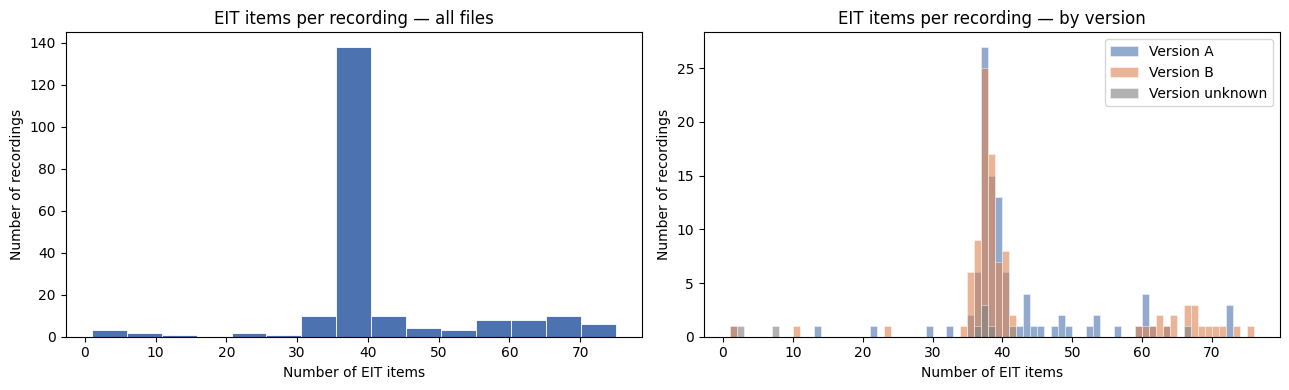

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
versions = sorted(df["version"].unique())
colors = {"A": "#4C72B0", "B": "#DD8452", "unknown": "#808080"}

# Left: overall histogram
ax = axes[0]
ax.hist(df["eit_items"], bins=15, color="#4C72B0", edgecolor="white", linewidth=0.6)
ax.set_title("EIT items per recording — all files", fontsize=12)
ax.set_xlabel("Number of EIT items")
ax.set_ylabel("Number of recordings")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Right: overlapping histograms by version
ax = axes[1]
bins = range(df["eit_items"].min(), df["eit_items"].max() + 2)
for ver in versions:
    subset = df[df["version"] == ver]["eit_items"]
    ax.hist(subset, bins=bins, alpha=0.6, label=f"Version {ver}",
            color=colors.get(ver, "gray"), edgecolor="white", linewidth=0.5)
ax.set_title("EIT items per recording — by version", fontsize=12)
ax.set_xlabel("Number of EIT items")
ax.set_ylabel("Number of recordings")
ax.legend()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

fig.tight_layout()
plt.savefig("../plots/eit_item_distribution.png", dpi=150)
plt.show()

## 3. VAD segments vs EIT items (collapse ratio)

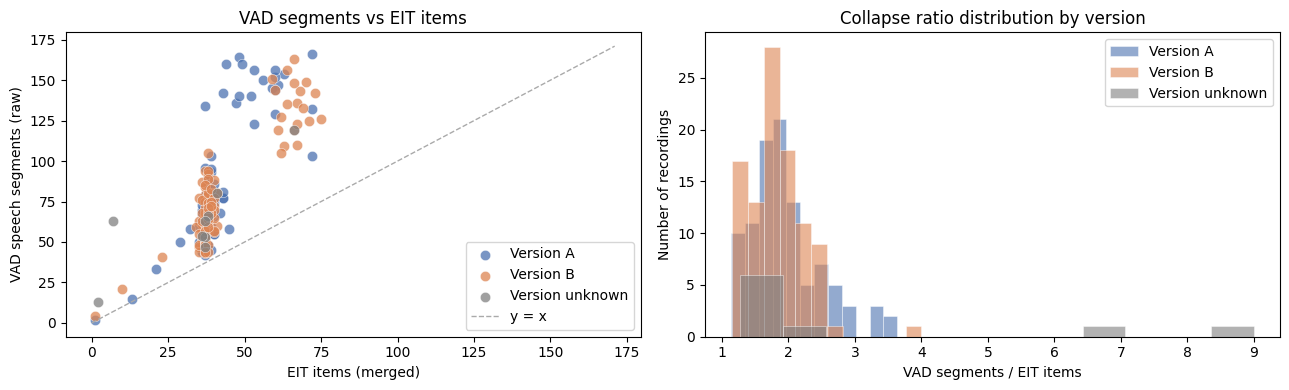

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter: VAD segments vs EIT items, coloured by version
ax = axes[0]
for ver in versions:
    sub = df[df["version"] == ver]
    ax.scatter(sub["eit_items"], sub["vad_segments"],
               label=f"Version {ver}", color=colors.get(ver, "gray"),
               alpha=0.75, edgecolors="white", linewidths=0.4, s=55)
# diagonal y=x reference
lim_max = max(df["vad_segments"].max(), df["eit_items"].max()) + 5
ax.plot([0, lim_max], [0, lim_max], "--", color="#aaaaaa", linewidth=1, label="y = x")
ax.set_xlabel("EIT items (merged)")
ax.set_ylabel("VAD speech segments (raw)")
ax.set_title("VAD segments vs EIT items", fontsize=12)
ax.legend()

# Histogram: collapse ratio
ax = axes[1]
for ver in versions:
    sub = df[df["version"] == ver]["collapse_ratio"]
    ax.hist(sub, bins=12, alpha=0.6, label=f"Version {ver}",
            color=colors.get(ver, "gray"), edgecolor="white", linewidth=0.5)
ax.set_xlabel("VAD segments / EIT items")
ax.set_ylabel("Number of recordings")
ax.set_title("Collapse ratio distribution by version", fontsize=12)
ax.legend()

fig.tight_layout()
plt.savefig("../plots/collapse_ratio.png", dpi=150)
plt.show()

## 4. ATTENTION flags — which files and which item indices

In [19]:
flagged = df[df["attention_count"] > 0][["file", "version", "eit_items", "attention_count"]].copy()
flagged["flagged_indices"] = flagged["file"].map(
    lambda f: attention_flags.get(f, [])
)

print(f"{len(flagged)} / {len(df)} recordings have at least one ATTENTION flag\n")
display(flagged.reset_index(drop=True))

134 / 206 recordings have at least one ATTENTION flag



,file,version,eit_items,attention_count,flagged_indices
0,038053_EITv-2A.mp3,A,39,1,[0]
1,038032_EITv-2A.mp3.mp3,unknown,37,1,[0]
2,038054_EITv-1A.mp3,A,39,1,[0]
3,038017_EIT-1A.mp3,A,37,1,[29]
4,038045_EITv-1A.mp3,A,39,1,[0]
...,...,...,...,...,...
129,038.104_EITv-2B.WMA,B,37,1,[0]
130,038.069_EITv-1B.WMA,B,38,1,[0]
131,038.075_EITv-1B.WMA,B,37,1,[0]
132,038.083_EITv-1B.WMA,B,39,1,[0]


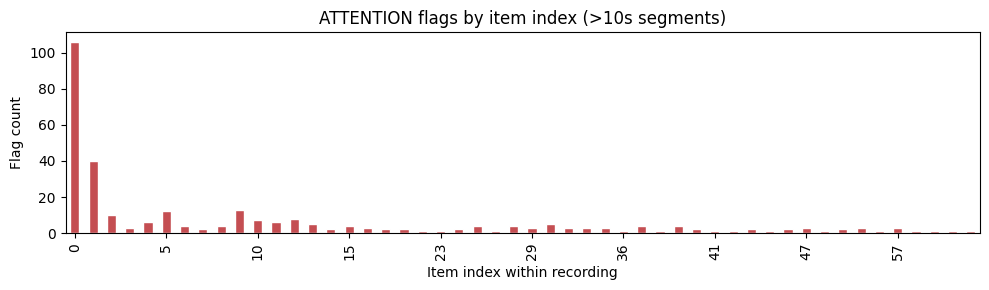

In [20]:
# Which item indices get flagged most often?
all_indices = [idx for idxs in attention_flags.values() for idx in idxs]
idx_series = pd.Series(all_indices, name="item_index")

fig, ax = plt.subplots(figsize=(10, 3))
idx_series.value_counts().sort_index().plot(kind="bar", ax=ax,
                                             color="#C44E52", edgecolor="white")
ax.set_title("ATTENTION flags by item index (>10s segments)", fontsize=12)
ax.set_xlabel("Item index within recording")
ax.set_ylabel("Flag count")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
fig.tight_layout()
plt.savefig("../plots/attention_by_index.png", dpi=150)
plt.show()

## 5. Anomalies — recordings with unexpectedly few EIT items

In [21]:
# Threshold: more than 2 std below the mean
mean_items = df["eit_items"].mean()
std_items  = df["eit_items"].std()
threshold  = mean_items - 2 * std_items

anomalies = df[df["eit_items"] < threshold][["file", "version", "vad_segments",
                                              "eit_items", "attention_count"]]
print(f"Mean EIT items: {mean_items:.1f}  |  Threshold (mean − 2σ): {threshold:.1f}")
print(f"{len(anomalies)} anomalous recording(s):\n")
display(anomalies.reset_index(drop=True))

Mean EIT items: 41.3  |  Threshold (mean − 2σ): 17.0
6 anomalous recording(s):



,file,version,vad_segments,eit_items,attention_count
0,038066_EITv-1A.mp3,A,2,1,1
1,038063_EITv-2A.mp3,A,15,13,0
2,038test_EITvA1.MP3,unknown,13,2,2
3,038065_EITv-1B.mp3,B,21,10,1
4,038039_EITv-2B.mp3,B,4,1,1
5,038test_EITvB2.MP3,unknown,63,7,2


## 6. Per-file item count — sorted bar chart

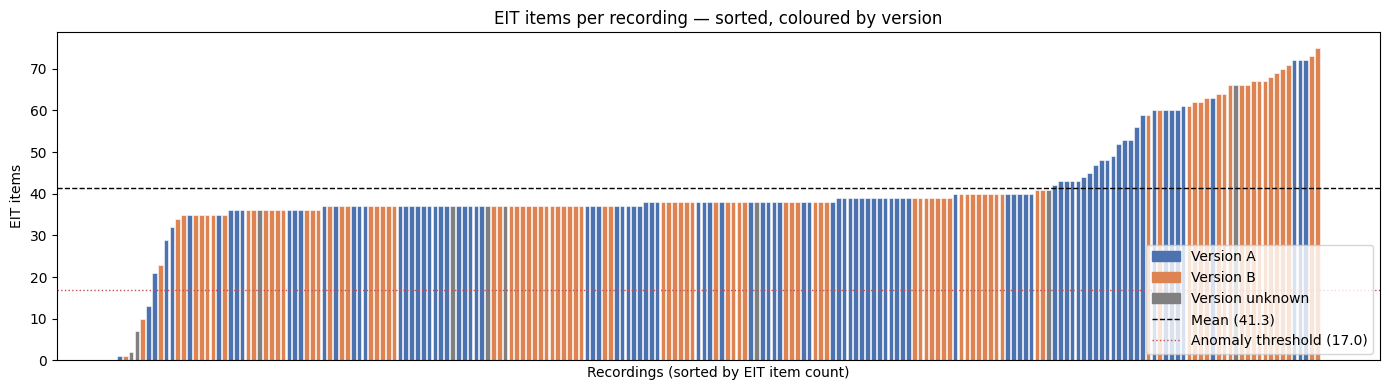

In [22]:
df_sorted = df.sort_values("eit_items")
bar_colors = [colors.get(v, "gray") for v in df_sorted["version"]]

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(range(len(df_sorted)), df_sorted["eit_items"],
               color=bar_colors, edgecolor="white", linewidth=0.4)

# Mean reference line
ax.axhline(mean_items, color="black", linestyle="--", linewidth=1,
           label=f"Mean ({mean_items:.1f})")
ax.axhline(threshold, color="#C44E52", linestyle=":", linewidth=1,
           label=f"Anomaly threshold ({threshold:.1f})")

# Legend patches for versions
from matplotlib.patches import Patch
legend_patches = [Patch(color=colors[v], label=f"Version {v}") for v in versions
                  if v in colors]
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0][-2:],
          loc="lower right")

ax.set_xticks([])
ax.set_xlabel("Recordings (sorted by EIT item count)")
ax.set_ylabel("EIT items")
ax.set_title("EIT items per recording — sorted, coloured by version", fontsize=12)
fig.tight_layout()
plt.savefig("../plots/per_file_items.png", dpi=150)
plt.show()

## 7. "Good" audio files

In [23]:
filtered = df[(df["eit_items"] > 31) & (df["eit_items"] < 40)]
table = filtered.groupby("version").size().reset_index(name="count")
total = pd.DataFrame([{"version": "Total", "count": len(filtered)}])
table = pd.concat([table, total], ignore_index=True)
display(table)

,version,count
0,A,64
1,B,65
2,unknown,5
3,Total,134
